# LOF -> LocalOutlier Factor - Revision Notes

## 1. Definition & Intuition

**Local Outlier Factor (LOF)** is an unsupervised anomaly detection algorithm that identifies observations whose local density is significantly lower than the density of their neighbouring observations.

Unlike Isolation Forest, which measures how easily an observation can be isolated using random splits, LOF compares the density of an observation with the density of its neighbours.

### Intuition with an example

Imagine a dataset containing two clusters:

* Cluster A: Houses priced between ₹40–60 lakh.
* Cluster B: Houses priced between ₹3–5 crore.

A house priced at ₹1 crore might be unusual compared with Cluster A but relatively inexpensive compared with Cluster B.

LOF attempts to identify observations that are unusual relative to their local neighbourhood rather than the entire dataset.

**Key idea:** An observation is potentially anomalous when its local density is significantly lower than the local density of its neighbours.

---

## 2. How LOF Works

LOF relies on four concepts.

### Step 1: Identify the k-nearest neighbours

For every observation, identify its `k` nearest neighbours using a distance metric, typically Euclidean distance.

For example, if `k = 5`, identify the five nearest observations to each point.

The parameter `k` determines the size of the neighbourhood used for comparison.

### Step 2: Calculate the k-distance

The k-distance of an observation `p` is the distance from `p` to its k-th nearest neighbour.

It helps define the neighbourhood of the observation.

__Simple Words__ : t is the maximum distance among the \(k\) nearest neighbours, when the neighbours are selected as the \(k\) closest points.

### Step 3: Calculate reachability distance

The reachability distance between observations `p` and `o` is:

reachability_distance_k(p, o) = max(k-distance(o), distance(p, o))

Here:

* `p` is the observation being evaluated.
* `o` is one of its neighbours.
* `distance(p, o)` is their actual distance.

**Intuition:** Reachability distance prevents extremely small distances in dense regions from dominating the density calculation. It uses the larger of the actual distance and the neighbour's k-distance.

### Step 4: Calculate local reachability density (LRD)

Local reachability density estimates how densely an observation is surrounded by its neighbours.

LRD(p) = 1 / average reachability distance between p and its k-nearest neighbours

Interpretation:

* Small average reachability distance → high local density.
* Large average reachability distance → low local density.

### Step 5: Calculate the LOF score

LOF compares the local reachability density of the neighbours with the local reachability density of the observation itself.

LOF_k(p) = Average [LRD(o) / LRD(p)] over the k-nearest neighbours `o` of `p`.

Interpretation:

* LOF ≈ 1: The observation has a density similar to its neighbours.
* LOF > 1: The observation has lower local density than its neighbours.
* LOF significantly greater than 1: The observation may be a local outlier.
* LOF < 1: The observation is locally denser than its neighbours.

The score is a relative measure, not a probability of being an anomaly.

---

## 3. Mathematical Foundation

### Reachability distance

reach-dist_k(p, o) = max{k-distance(o), d(p, o)}

### Local reachability density

LRD_k(p) = 1 / [average reachability distance from p to its k-nearest neighbours]

### Local Outlier Factor

LOF_k(p) = (1 / |N_k(p)|) × Σ [LRD_k(o) / LRD_k(p)]

Where:

* `N_k(p)` = k-nearest neighbours of observation `p`.
* `LRD_k(p)` = local reachability density of observation `p`.
* `LRD_k(o)` = local reachability density of neighbour `o`.

**Mathematical intuition:** If an observation has much lower local density than its neighbours, the ratios of neighbour densities to its own density become larger, producing a higher LOF score.

---

## 4. Example: Understanding LOF Scores

Suppose an observation has a local reachability density of `0.1`, while its five neighbours have an average local reachability density of `0.5`.

LOF(p) = 0.5 / 0.1 = 5

The observation's neighbours are, on average, five times as locally dense as the observation itself. This suggests that the observation may be a local outlier.

Compare three hypothetical cases:

| LOF score | Interpretation                         |
| --------- | -------------------------------------- |
| 1.0       | Density similar to neighbours          |
| 1.5       | Somewhat lower density than neighbours |
| 5.0       | Much lower density than neighbours     |

These values are illustrative. There is no universal LOF threshold that works for every dataset.

---

## 5. Hyperparameters

### `n_neighbors`

Controls how many neighbours are considered when estimating local density.

* Small `k`: More sensitive to small, local irregularities; potentially more sensitive to noise.
* Large `k`: Considers a broader neighbourhood; may smooth out small local anomalies.

### `metric`

Distance metric used to identify neighbours, such as Euclidean or Manhattan distance.

### `contamination`

Expected proportion of outliers, used to determine the threshold for classifying observations as outliers.

### `novelty`

Controls whether LOF is used for detecting anomalies in new, unseen observations.

* `novelty=False`: Standard outlier detection on the fitted dataset.
* `novelty=True`: Novelty detection for unseen observations.

Important: When `novelty=True`, use the novelty-scoring methods on new observations rather than treating their outputs on the training data as equivalent to standard LOF outlier detection.

---

## 6. Advantages

1. **Detects local outliers:** Identifies observations that are unusual relative to their neighbours, even when they are not globally unusual.
2. **Handles clusters with different densities:** Can identify local anomalies across groups with different density levels, provided the neighbourhood size is appropriate.
3. **No labelled data required:** Works as an unsupervised anomaly detection method.

## 7. Limitations

1. **Sensitive to the choice of `k`:** A neighbourhood that is too small or too large can lead to misleading anomaly scores.
2. **Distance and scaling matter:** Features with larger numerical scales can dominate distance calculations, so appropriate feature scaling is often necessary.
3. **Computationally expensive on large datasets:** Finding nearest neighbours can become costly as the dataset grows, although optimized neighbour-search algorithms can help.

---

## 8. LOF vs Isolation Forest

| Aspect                | LOF                                  | Isolation Forest                                                           |
| --------------------- | ------------------------------------ | -------------------------------------------------------------------------- |
| Core idea             | Compares local densities             | Measures ease of isolation                                                 |
| Main mechanism        | Nearest neighbours and distances     | Random feature selection and splits                                        |
| Local outliers        | Specifically designed to detect them | Can detect them, but not explicitly designed for local density comparisons |
| Distance calculations | Required                             | Not explicitly required                                                    |
| Feature scaling       | Often important                      | Generally less sensitive to scale                                          |
| Main parameter        | `n_neighbors`                        | `max_samples`, `n_estimators`                                              |
| Computational concern | Nearest-neighbour search             | Building and evaluating isolation trees                                    |

---

## 9. Scikit-learn Implementation

```python
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

# X contains numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize LOF
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination="auto"
)

# Fit and classify observations in the dataset
labels = lof.fit_predict(X_scaled)

# +1 = inlier, -1 = outlier
print(labels)

# Access LOF scores for the fitted observations
scores = lof.negative_outlier_factor_
print(scores)
```

### Understanding scikit-learn outputs

* `fit_predict(X)`: Returns `+1` for inliers and `-1` for outliers.
* `negative_outlier_factor_`: Contains the negative LOF scores for the fitted observations.
* Because scikit-learn stores negative LOF scores, **more negative values indicate stronger outlier behaviour**.
* `contamination`: Influences the decision threshold, not the underlying neighbourhood density calculation.

---

## 10. Real-World Applications

* **Fraud detection:** Identify transactions that are unusual compared with similar transactions.
* **Manufacturing:** Detect products whose measurements differ from those of nearby or similar products.
* **Customer analytics:** Identify customers with unusual behaviour relative to comparable customer segments.
* **Network monitoring:** Identify activity that differs from the behaviour of nearby observations in feature space.

LOF scores should be treated as anomaly indicators, not definitive proof of fraud or abnormal behaviour.

---

## 11. Interview Questions to Revise

1. What is Local Outlier Factor, and how does it differ from Isolation Forest?
2. What is local reachability density?
3. Why does LOF use reachability distance instead of only Euclidean distance?
4. What does an LOF score of 1 indicate?
5. What happens when `n_neighbors` is too small or too large?
6. Why is feature scaling important for LOF?
7. How can LOF identify local outliers when clusters have different densities?
8. What is the difference between outlier detection and novelty detection in scikit-learn?
9. Why is LOF not a probability score?
10. What are the computational limitations of LOF?

---

## 12. One-Minute Interview Answer

“Local Outlier Factor is an unsupervised anomaly detection algorithm that identifies observations whose local density is significantly lower than that of their nearest neighbours. It first identifies the k-nearest neighbours, calculates reachability distances, estimates local reachability density, and then compares the density of an observation with the average density of its neighbours. A score close to 1 indicates similar local density, while a substantially higher score indicates potential local outlier behaviour. LOF is particularly useful when local anomalies exist in datasets containing groups with different densities. Its main limitations are sensitivity to the number of neighbours, dependence on distance metrics and feature scaling, and the computational cost of nearest-neighbour searches.”

## Quick Revision Summary

* **Definition:** Detects observations with lower local density than their neighbours.
* **Core mechanism:** k-nearest neighbours → reachability distance → local reachability density → LOF score.
* **LOF ≈ 1:** Similar local density.
* **LOF > 1:** Lower density than neighbours.
* **High LOF:** Potential local outlier.
* **Main parameter:** `n_neighbors`.
* **Key advantage:** Detects local anomalies.
* **Key limitation:** Sensitive to neighbourhood size and distance calculations.
* **Comparison:** LOF compares relative local density; Isolation Forest measures ease of isolation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

          x         y
0  6.800000  3.800000
1  6.254355  4.724891
2 -0.254012  0.077306
3 -0.081144  0.406390
4  0.701766  0.081591
(188, 2)


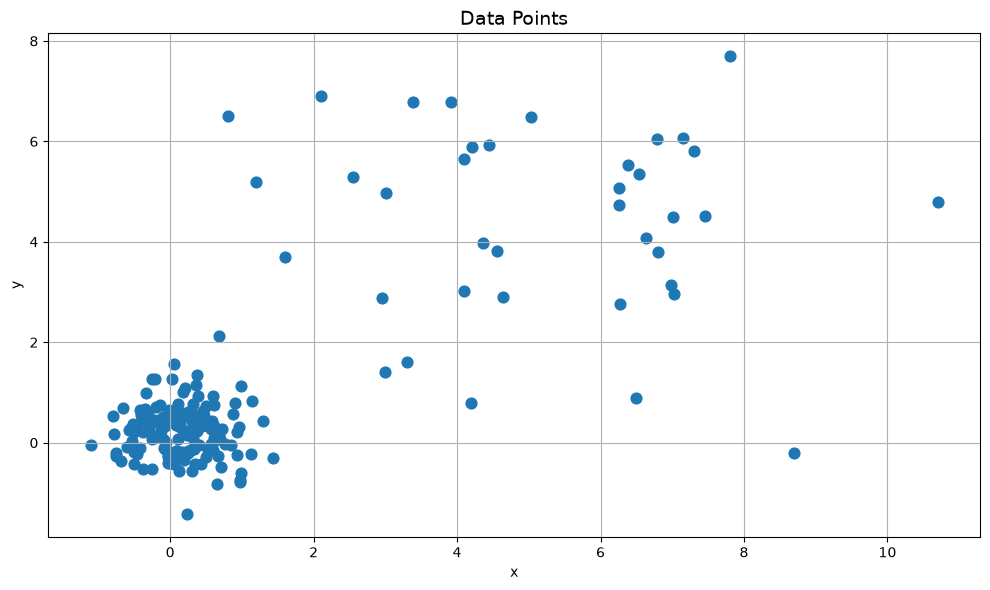

In [2]:
# Reproducibility
np.random.seed(42)

# ---------------- Generate points ----------------

# Dense blob near (0, 0)
n_blob = 150
blob_x = np.random.normal(loc=0.2, scale=0.5, size=n_blob)
blob_y = np.random.normal(loc=0.2, scale=0.5, size=n_blob)

# Sparse spread in the upper-middle region
n_spread = 25
spread_x = np.random.uniform(2.5, 7.5, n_spread)
spread_y = np.random.uniform(2.5, 7.0, n_spread)

# Scattered far-away points
far_points = np.array([
    [0.8, 6.5], [1.2, 5.2], [1.6, 3.7], [2.1, 6.9],
    [3.0, 1.4], [3.3, 1.6], [4.2, 0.8], [6.5, 0.9],
    [6.8, 3.8], [7.3, 5.8], [7.8, 7.7], [8.7, -0.2],
    [10.7, 4.8],
])

x = np.concatenate([blob_x, spread_x, far_points[:, 0]])
y = np.concatenate([blob_y, spread_y, far_points[:, 1]])

# ---------------- DataFrame ----------------

data = pd.DataFrame({"x": x, "y": y})
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print(data.head())
print(data.shape)

# ---------------- Plot ----------------

plt.figure(figsize=(10, 6))
plt.scatter(data["x"], data["y"], c="tab:blue", s=60)

plt.title("Data Points", fontsize=14)
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.tight_layout()
plt.show()

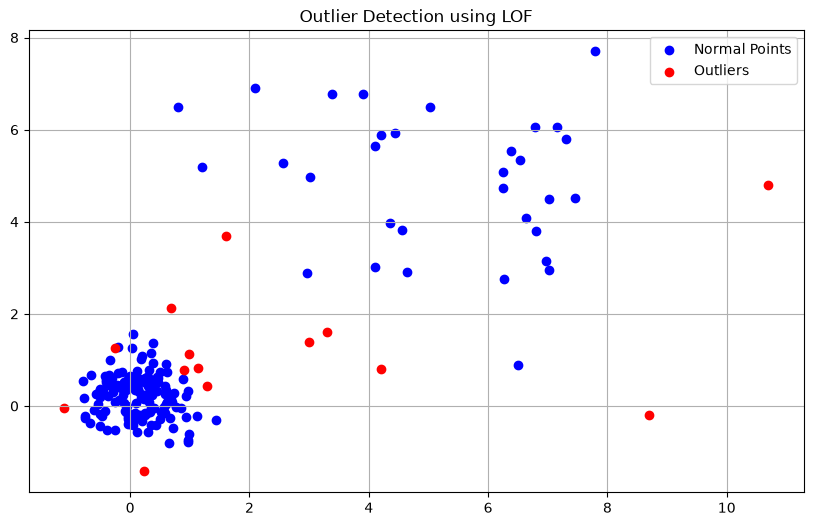

In [3]:
# Applying LOF
clf_lof = LocalOutlierFactor(n_neighbors=10, contamination=0.07)
y_pred_lof = clf_lof.fit_predict(data)
lof_scores = -clf_lof.negative_outlier_factor_  # Inverting the negative LOF scores for better interpretation

# Identifying the outliers based on the LOF prediction
is_outlier_lof = y_pred_lof == -1

# Plotting the results
# Plot the first two columns of the DataFrame
plt.figure(figsize=(10, 6))
plt.scatter(data.iloc[~is_outlier_lof, 0],
            data.iloc[~is_outlier_lof, 1],
            color="blue", label="Normal Points")
plt.scatter(data.iloc[is_outlier_lof, 0],
            data.iloc[is_outlier_lof, 1],
            color="red", label="Outliers")

plt.title("Outlier Detection using LOF")
plt.legend()
plt.grid(True)
plt.show()